# Exercícios — Dados Faltantes e Outliers

**Tema:** Preparação de Dados › Dados Faltantes e Outliers

Resolva antes de olhar o gabarito. **Dificuldade:** 🟢 base · 🟡 aplicação ·
🔴 síntese

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(456)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("ambiente pronto")

ambiente pronto


---
## Exercício 1 🟢 — Classificando o mecanismo

Para cada cenário, classifique o mecanismo de ausência como MCAR, MAR ou
MNAR, e justifique em uma frase:

1. Um formulário online perde respostas aleatoriamente por falha de rede.
2. Clientes com menos de 1 ano de conta têm mais campos de perfil
   incompletos (o app pede menos informação nos primeiros meses).
3. Pacientes com sintomas muito leves ou ausentes têm menor chance de
   retornar para um exame de acompanhamento, deixando o resultado do exame
   ausente.

In [2]:
# --- sua resposta ---

### Gabarito 1

In [3]:
respostas = {
    1: "MCAR — a falha de rede não depende do valor da resposta nem de "
       "nenhuma variável observada do cliente.",
    2: "MAR — a ausência depende de 'tempo de conta', uma variável OBSERVADA, "
       "não do próprio valor do campo de perfil.",
    3: "MNAR — a ausência depende diretamente da gravidade dos sintomas, que "
       "é justamente o que o exame mediria; pacientes leves E ausentes "
       "puxam a amostra observada para os casos mais graves.",
}
for k, v in respostas.items():
    print(f"{k}. {v}\n")

1. MCAR — a falha de rede não depende do valor da resposta nem de nenhuma variável observada do cliente.

2. MAR — a ausência depende de 'tempo de conta', uma variável OBSERVADA, não do próprio valor do campo de perfil.

3. MNAR — a ausência depende diretamente da gravidade dos sintomas, que é justamente o que o exame mediria; pacientes leves E ausentes puxam a amostra observada para os casos mais graves.



---
## Exercício 2 🟢 — Diagnóstico com regressão logística

Gere uma variável `x` (idade) e uma variável `y` com 30% de nulos que
dependem de `x` (MAR: quanto maior `x`, maior a chance de nulo). Treine uma
regressão logística prevendo "é nulo?" a partir de `x` e reporte o AUC.
Repita apagando `y` de forma MCAR (independente de `x`) e compare o AUC.

In [4]:
# --- sua resposta ---

### Gabarito 2

In [5]:
n = 2000
x = rng.normal(45, 15, n).clip(18, 90)
y = rng.normal(0, 1, n)

prob_mar = 0.10 + 0.6 * (x - x.min()) / (x.max() - x.min())
nulo_mar = rng.random(n) < prob_mar
nulo_mcar = rng.random(n) < 0.30

for nome, mascara in [("MAR", nulo_mar), ("MCAR", nulo_mcar)]:
    modelo = LogisticRegression().fit(x.reshape(-1, 1), mascara.astype(int))
    auc = roc_auc_score(mascara.astype(int), modelo.predict_proba(x.reshape(-1, 1))[:, 1])
    print(f"{nome}: AUC prevendo nulo a partir de x = {auc:.3f}")

MAR: AUC prevendo nulo a partir de x = 0.668
MCAR: AUC prevendo nulo a partir de x = 0.530


**Resposta esperada:** o AUC do cenário MAR fica nitidamente acima de 0,5
(x prevê a ausência); o do MCAR fica perto de 0,5 (x não carrega informação
sobre a ausência). Esse é o teste prático mais simples para diferenciar os
dois — mas lembre-se do notebook-guia: ele não detecta MNAR.

---
## Exercício 3 🟡 — Comparando imputações contra o gabarito

Usando os mesmos `x` e `y` do exercício 2 (cenário MAR), impute os nulos de
`y` com (a) a média e (b) `KNNImputer` usando `x` como vizinhança. Como você
não tem outras colunas correlacionadas com `y` neste exercício (`y` foi
gerado independente de `x`), o que você espera que aconteça com o
desempenho do KNN comparado à média?

In [6]:
# --- sua resposta ---

### Gabarito 3

In [7]:
y_com_nulo = y.copy()
y_com_nulo[nulo_mar] = np.nan
y_verdadeiro_nos_nulos = y[nulo_mar]

media_imputada = SimpleImputer(strategy="mean").fit_transform(
    y_com_nulo.reshape(-1, 1)).ravel()

dados_knn = np.column_stack([x, y_com_nulo])
knn_imputado = KNNImputer(n_neighbors=10).fit_transform(dados_knn)[:, 1]

erro_media = np.abs(media_imputada[nulo_mar] - y_verdadeiro_nos_nulos).mean()
erro_knn = np.abs(knn_imputado[nulo_mar] - y_verdadeiro_nos_nulos).mean()
print(f"erro absoluto médio (média): {erro_media:.4f}")
print(f"erro absoluto médio (KNN)  : {erro_knn:.4f}")

erro absoluto médio (média): 0.7614
erro absoluto médio (KNN)  : 0.7931


**Resposta:** como `y` foi construído **independente** de `x`, `x` não
carrega nenhuma informação real sobre o valor de `y` — então o KNN não deve
performar melhor que a média (pode até performar pior, por ruído de
amostragem finita). A lição: imputação sofisticada só ajuda quando existe
de fato relação entre as colunas usadas e a coluna imputada. Usar KNN ou
MICE não é uma garantia de melhora — é uma aposta de que a estrutura entre
colunas existe e é capturável.

---
## Exercício 4 🟡 — Z-score vs. IQR em dados assimétricos

Gere uma variável log-normal (assimetria à direita, como em dados de
receita/tempo). Aplique a regra do IQR e o z-score modificado para detectar
outliers. Eles concordam? A distribuição assimétrica favorece algum dos
dois métodos a marcar falsos positivos em um dos lados?

In [8]:
# --- sua resposta ---

### Gabarito 4

z-score modificado detectou: 168 pontos
IQR detectou               : 189 pontos
concordância (ambos marcam): 168
só z-score modificado      : 0
só IQR                     : 21


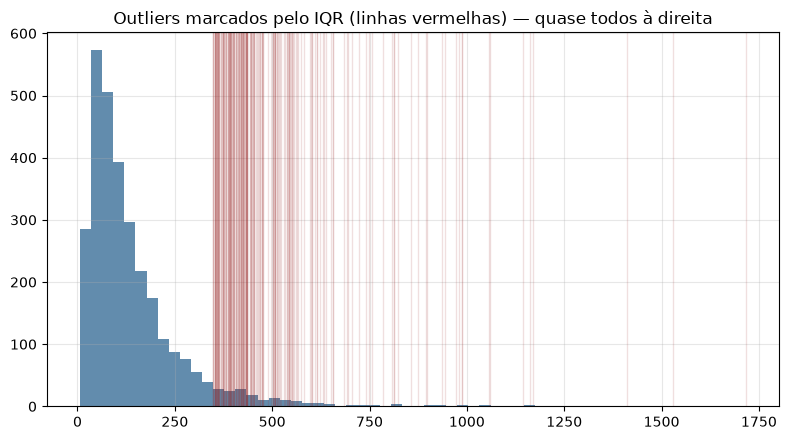

In [9]:
valores_lognormal = rng.lognormal(mean=np.log(100), sigma=0.8, size=3000)


def z_score_modificado(v):
    mediana = np.median(v)
    mad = np.median(np.abs(v - mediana))
    return 0.6745 * (v - mediana) / mad


def deteccao_iqr(v, fator=1.5):
    q1, q3 = np.percentile(v, [25, 75])
    iqr = q3 - q1
    return (v < q1 - fator * iqr) | (v > q3 + fator * iqr)


det_zm = np.abs(z_score_modificado(valores_lognormal)) > 3.5
det_iqr = deteccao_iqr(valores_lognormal)

print(f"z-score modificado detectou: {det_zm.sum()} pontos")
print(f"IQR detectou               : {det_iqr.sum()} pontos")
print(f"concordância (ambos marcam): {(det_zm & det_iqr).sum()}")
print(f"só z-score modificado      : {(det_zm & ~det_iqr).sum()}")
print(f"só IQR                     : {(~det_zm & det_iqr).sum()}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(valores_lognormal, bins=60, color=AZUL, alpha=0.7)
for v in valores_lognormal[det_iqr]:
    ax.axvline(v, color=VERMELHO, alpha=0.15, lw=1)
ax.set_title("Outliers marcados pelo IQR (linhas vermelhas) — quase todos à direita")
plt.tight_layout(); plt.show()

**Resposta esperada:** os dois métodos concordam na maioria dos casos, mas
ambos marcam outliers **quase exclusivamente à direita** — efeito esperado
em dados log-normais, onde a cauda pesada é de valores altos, não baixos.
Isso não é um erro dos métodos: é o dado sendo genuinamente assimétrico.
Um lembrete prático do tema 1: para esse tipo de variável, considerar a
transformação log **antes** de aplicar qualquer regra de detecção costuma
ser mais informativo do que aplicar a regra na escala original.

---
## Exercício 5 🔴 — Auditoria completa: nulos + outliers no mesmo pipeline

Um dataset de avaliações de crédito tem: `renda` (15% de nulos, MAR — depende
de `idade`), e valores de `renda` com outliers genuínos (poucos clientes de
renda muito alta, reais, não erro). Construa o dataset, e responda: em que
ORDEM você trataria nulos e outliers, e por quê? Implemente sua escolha e
justifique com uma comparação (trate na ordem que você escolheu vs. na ordem
inversa) do efeito sobre a média final de `renda`.

In [10]:
# --- sua resposta ---

### Gabarito 5

In [11]:
n = 3000
idade = rng.normal(40, 12, n).clip(18, 75)
renda_base = (1500 + 100 * idade + rng.normal(0, 800, n)).clip(700, None)
# poucos clientes de renda muito alta, REAIS (não erro)
indices_altos = rng.choice(n, size=40, replace=False)
renda_base[indices_altos] *= rng.uniform(4, 9, 40)

prob_nulo = 0.05 + 0.3 * (idade - idade.min()) / (idade.max() - idade.min())
mascara_nulo = rng.random(n) < prob_nulo
renda_com_nulo = renda_base.copy()
renda_com_nulo[mascara_nulo] = np.nan

df = pd.DataFrame({"idade": idade, "renda": renda_com_nulo})
media_verdadeira = renda_base.mean()

# ORDEM A: detectar outliers primeiro (nos dados observados), depois imputar
def deteccao_iqr(v, fator=1.5):
    q1, q3 = np.nanpercentile(v, [25, 75])
    iqr = q3 - q1
    return (v < q1 - fator * iqr) | (v > q3 + fator * iqr)


outliers_a = deteccao_iqr(df["renda"].to_numpy())
df_a = df.copy()
df_a.loc[outliers_a, "renda"] = np.nan  # trata outlier como nulo também
imputado_a = KNNImputer(n_neighbors=10).fit_transform(df_a[["idade", "renda"]])[:, 1]

# ORDEM B: imputar primeiro, depois detectar outliers no resultado já imputado
imputado_b_bruto = KNNImputer(n_neighbors=10).fit_transform(df[["idade", "renda"]])[:, 1]
outliers_b = deteccao_iqr(imputado_b_bruto)
imputado_b = np.where(outliers_b, np.nan, imputado_b_bruto)

print(f"média verdadeira (dados completos, sem apagar nada): {media_verdadeira:.1f}\n")
print(f"ORDEM A (outlier -> nulo -> imputa)   : média = {np.nanmean(imputado_a):.1f}  "
      f"outliers reais perdidos: {outliers_a[indices_altos].sum()} de 40")
print(f"ORDEM B (imputa -> detecta outlier)   : média = {np.nanmean(imputado_b):.1f}  "
      f"outliers reais 'perdidos' na detecção final: {outliers_b[indices_altos].sum()} de 40")

média verdadeira (dados completos, sem apagar nada): 5920.2

ORDEM A (outlier -> nulo -> imputa)   : média = 5505.5  outliers reais perdidos: 34 de 40
ORDEM B (imputa -> detecta outlier)   : média = 5533.9  outliers reais 'perdidos' na detecção final: 35 de 40


**Resposta esperada:** tratar outliers **antes** de imputar (Ordem A) corre
o risco de tratar clientes de renda genuinamente alta como nulos e depois
"inventar" uma renda mais modesta para eles via KNN — apagando um sinal real
no processo. A ordem mais defensável, na maioria dos casos, é: **investigar
outliers primeiro só como diagnóstico (sem alterar os dados)**, decidir se
são erro ou sinal real, imputar os nulos genuínos separadamente, e só então
(se ainda fizer sentido) tratar os outliers confirmados como erro. Não existe
uma ordem universal — o que não pode acontecer é tratar outliers
automaticamente como se fossem nulos sem essa investigação, porque isso mistura
dois problemas com causas e soluções diferentes.

---
## Fechamento

- MCAR, MAR e MNAR não são exercício teórico: preveem o viés que aparece
  quando o mecanismo errado é assumido.
- Imputação sofisticada (KNN, MICE) só ajuda quando existe estrutura real
  entre as colunas — não é uma melhoria automática.
- Z-score clássico e outliers extremos têm uma relação circular; prefira
  métodos robustos (mediana/MAD, IQR).
- Nulos e outliers são problemas diferentes, com causas diferentes — misturar
  o tratamento dos dois sem investigar cada caso é a forma mais comum de
  destruir sinal real em nome de "limpar os dados".

→ Próximo módulo: **Feature Engineering**, onde os dados já limpos viram
variáveis que de fato ajudam o modelo a aprender.